In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import CubicSpline
from scipy.interpolate import PchipInterpolator

## a)

In [4]:
data = np.array([[ 203.41 , -89.37 ],
[ 203.435, -94.88 ],
[ 203.46 , -101.25 ],
[ 203.484, -106.52 ],
[ 203.509, -108.66 ],
[ 203.534, -114.25 ],
[ 203.558, -114.30 ],
[ 203.583, -117.66 ],
[ 203.608, -122.45 ]])

sol = data[:,0]
temp = data[:,1]

In [5]:
cubspline = CubicSpline(sol, temp)

linTemp = np.interp(203.57, sol, temp)
cubTemp = cubspline(203.57)
print(f"The estimate of the temperature at sol 203.57 is ({linTemp:.3f} +/- 0.001) °C using linear interpolation \n and ({cubTemp:.3f} +/- 0.001) °C using cubic spline interpolation.")

The estimate of the temperature at sol 203.57 is (-115.913 +/- 0.001) °C using linear interpolation 
 and (-115.325 +/- 0.001) °C using cubic spline interpolation.


## b)

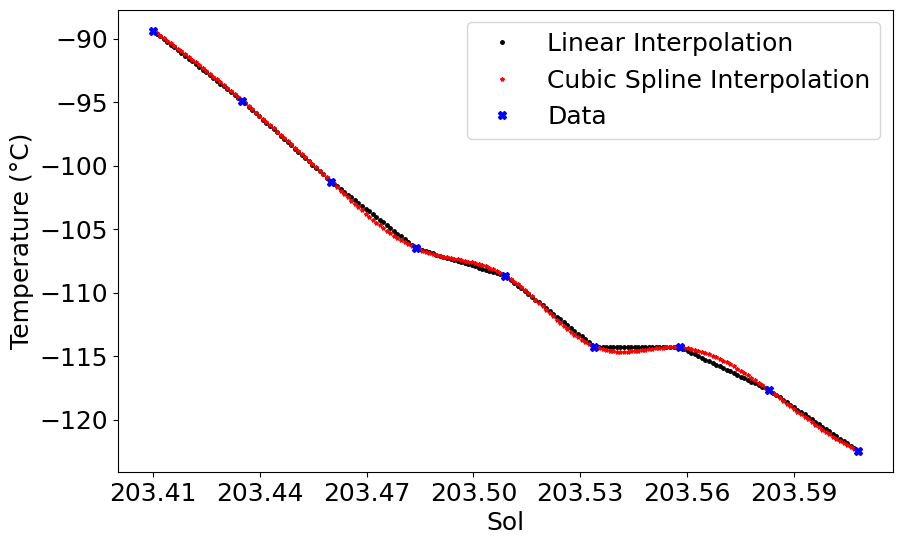

In [6]:
xx = np.linspace(sol[0], sol[-1], 200)
ylin = np.interp(xx, sol, temp)

ycub = cubspline(xx)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(xx, ylin, 'k.', markersize=5, label='Linear Interpolation')
ax.plot(xx, ycub, 'r*', markersize=3, label='Cubic Spline Interpolation')
ax.plot(sol, temp, 'bX', label='Data')
ax.legend(fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=8))
ax.set_xlabel('Sol', fontsize=18)
ax.set_ylabel('Temperature (°C)', fontsize=18);
fig.savefig("5b.pdf");

In [7]:
idxs = np.where(np.diff(ycub) > 0)[0]
print(np.diff(idxs))
xxInc = xx[idxs+1]
print(f"The interval of sol values where the cubic spline interpolation is increasing are: [{xxInc[0]:.3f}; {xxInc[-1]:.3f}] ")

[1 1 1 1 1 1 1 1 1 1 1 1 1 1]
The interval of sol values where the cubic spline interpolation is increasing are: [203.542; 203.556] 


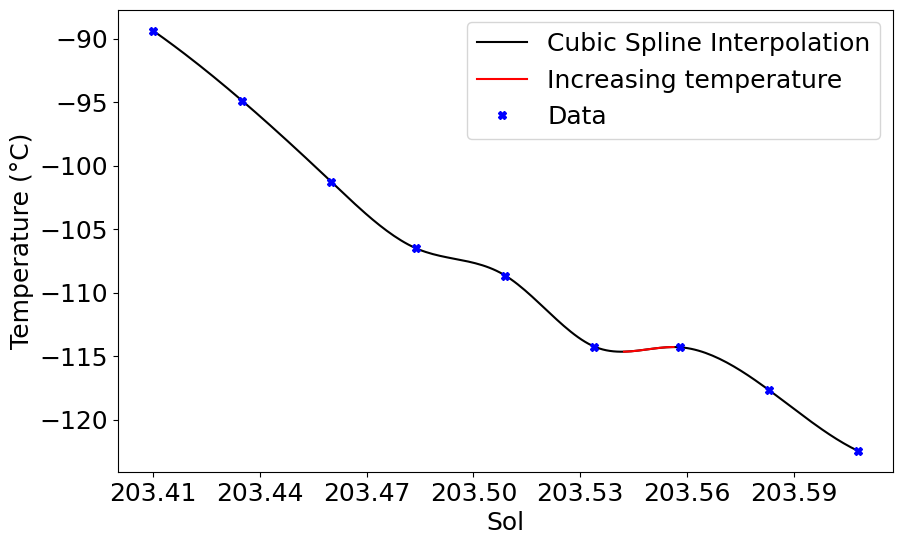

In [19]:
ycub = cubspline(xx)
ycubInc = cubspline(xxInc)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(xx, ycub, 'k', label='Cubic Spline Interpolation')
ax.plot(xxInc, ycubInc, 'r-', label='Increasing temperature')
ax.plot(sol, temp, 'bX', label='Data')
ax.legend(fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=8))
ax.set_xlabel('Sol', fontsize=18)
ax.set_ylabel('Temperature (°C)', fontsize=18);
fig.savefig("5b_2.pdf");

In [14]:
pchip = PchipInterpolator(sol, temp)
ypchip = pchip(xx)
idxs2 = np.where(np.diff(ypchip) > 0)[0]
print(np.diff(idxs2))

[]


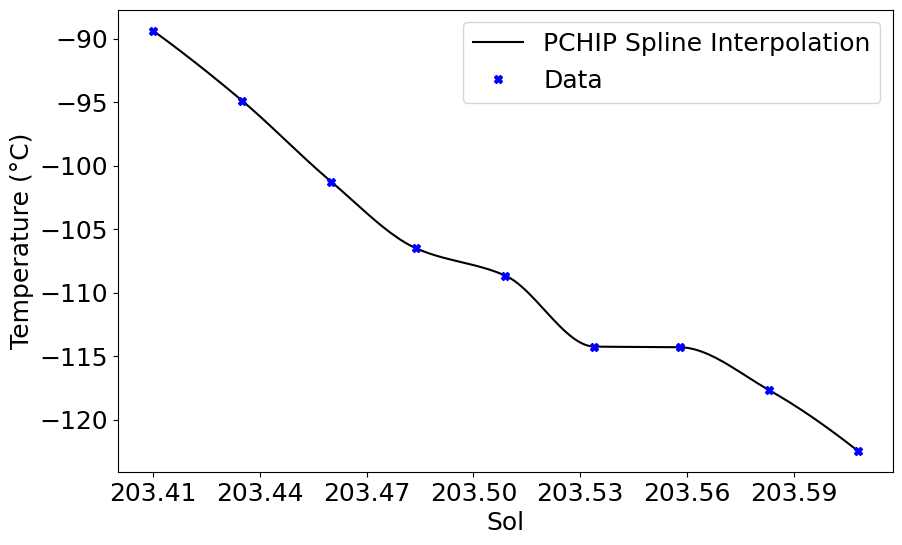

In [26]:
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(xx, ypchip, 'k', label='PCHIP Spline Interpolation')
ax1.plot(sol, temp, 'bX', label='Data')
ax1.legend(fontsize=18)
ax1.tick_params(axis='both', which='major', labelsize=18)
ax1.xaxis.set_major_locator(plt.MaxNLocator(nbins=8))
ax1.set_xlabel('Sol', fontsize=18)
ax1.set_ylabel('Temperature (°C)', fontsize=18);
fig.savefig("5b_3.pdf");

## c)

In [10]:
xx2 = np.arange(sol[0], sol[-1], 0.0004)
print(len(xx2))
ylin2 = np.interp(xx2, sol, temp)

ycub2 = cubspline(xx2)

linDiff = np.diff(ylin2)
cubDiff = np.diff(ycub2)
print(f"The maximum absolute temp change within 0.0004 sol according to linear spline is {np.max(np.abs(linDiff)):.3f} \n  and according to cubic spline it's {np.max(np.abs(cubDiff)):.3f}")

496
The maximum absolute temp change within 0.0004 sol according to linear spline is 0.102 
  and according to cubic spline it's 0.106
